In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Config

In [2]:
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
CHECKPOINT_PATH = "/kaggle/working/checkpoint.pth"

MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 3
LR = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load Data

In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/muqaddasejaz/ai-vs-human-text-dataset/AI_Human.csv')

In [4]:
df.head()

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [5]:
# First let's check whether there is duplicate data and if there is let's remove them.
df.duplicated().sum()

np.int64(0)

There is no duplicate values in this dataset therefore there is no need to remove duplicate values

In [6]:
# Let's check missing values in the dataset
df.isna().sum()

text         0
generated    0
dtype: int64

There is also no missing value therefore also no need to handle them.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  object 
 1   generated  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB


In [8]:
# Check count of AI generated and Human
df['generated'].value_counts()

generated
0.0    305797
1.0    181438
Name: count, dtype: int64

According to the above data there is class imbalance in this dataset. That means we have to handle this class imbalance.
- **Human : 305797**
- **AI : 181438**

We will handle this class this imbalance using class weights

# 4. Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['generated'], stratify = df['generated'])

# 5. DATASET CLASS

In [10]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length = self.max_len,
            padding = "max_length",
            truncation = True, 
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

In [11]:
class BERTClassifier(nn.Module):
    def __init__(self, num_labels=2):
        super().__init__()

        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size = self.bert.config.hidden_size

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls)
        logits = self.fc(x)

        return logits

In [12]:
def get_class_weights(labels):
    labels = torch.tensor(labels).long()
    counts = torch.bincount(labels)

    weights = len(labels) / (len(counts) * counts.float())
    return weights.to(DEVICE)

In [13]:
def save_checkpoint(model, optimizer, epoch, batch_idx):
    torch.save({
        "model": model.module.state_dict() if hasattr(model, "module") else model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,
        "batch_idx": batch_idx
    }, CHECKPOINT_PATH)

In [24]:
def save_model(model, optimizer, tokenizer):
    os.makedirs("./model", exist_ok=True)
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": EPOCHS,
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_len": MAX_LEN
    }, "./model/model.pth")
    tokenizer.save_pretrained("./model/tokenizer/")
    print("Model Saved.")

In [15]:
def load_checkpoint(model, optimizer):
    if os.path.exists(CHECKPOINT_PATH):
        print("🔄 Loading from checkpoint...")

        ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

        model.module.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])

        return ckpt["epoch"], ckpt["batch_idx"]

    return 0, 0

In [16]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [17]:
texts = X_train.to_numpy()
labels = y_train.to_numpy()

In [18]:
dataset = TextDataset(texts, labels, tokenizer, MAX_LEN)

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [19]:
model = BERTClassifier()

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model = model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=2e-5)

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using 2 GPUs


In [20]:
class_weights = get_class_weights(labels)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [21]:
start_epoch, start_batch = load_checkpoint(model, optimizer)

In [22]:
model.train()

for epoch in range(start_epoch, EPOCHS):

    total_loss = 0.0
    total_batches = 0
    
    for batch_idx, batch in enumerate(loader):

        if epoch == start_epoch and batch_idx < start_batch:
            continue

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE).long()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        total_batches += 1

        
        print(f"Epoch {epoch} Batch {batch_idx} Loss {loss.item():.4f}")

        save_checkpoint(model, optimizer, epoch, batch_idx)

    epoch_loss = total_loss / total_batches
    print(f"\n✅ Epoch {epoch} Completed | Average Loss: {epoch_loss:.4f}\n")
    
    start_batch = 0
save_model(model, optimizer, tokenizer)

Epoch 0 Batch 0 Loss 0.7236
Epoch 0 Batch 1 Loss 0.6757
Epoch 0 Batch 2 Loss 0.6731
Epoch 0 Batch 3 Loss 0.7306
Epoch 0 Batch 4 Loss 0.6771
Epoch 0 Batch 5 Loss 0.7141
Epoch 0 Batch 6 Loss 0.7078
Epoch 0 Batch 7 Loss 0.6966
Epoch 0 Batch 8 Loss 0.6815
Epoch 0 Batch 9 Loss 0.6832
Epoch 0 Batch 10 Loss 0.6583
Epoch 0 Batch 11 Loss 0.6664
Epoch 0 Batch 12 Loss 0.6622
Epoch 0 Batch 13 Loss 0.6597
Epoch 0 Batch 14 Loss 0.6649
Epoch 0 Batch 15 Loss 0.6618
Epoch 0 Batch 16 Loss 0.6342
Epoch 0 Batch 17 Loss 0.6429
Epoch 0 Batch 18 Loss 0.6379
Epoch 0 Batch 19 Loss 0.6326
Epoch 0 Batch 20 Loss 0.6015
Epoch 0 Batch 21 Loss 0.6343
Epoch 0 Batch 22 Loss 0.6310
Epoch 0 Batch 23 Loss 0.6190
Epoch 0 Batch 24 Loss 0.5855
Epoch 0 Batch 25 Loss 0.5997
Epoch 0 Batch 26 Loss 0.6196
Epoch 0 Batch 27 Loss 0.5777
Epoch 0 Batch 28 Loss 0.5829
Epoch 0 Batch 29 Loss 0.4963
Epoch 0 Batch 30 Loss 0.4563
Epoch 0 Batch 31 Loss 0.5153
Epoch 0 Batch 32 Loss 0.5549
Epoch 0 Batch 33 Loss 0.4748
Epoch 0 Batch 34 Loss 0.

RuntimeError: Parent directory /model does not exist.

In [25]:
save_model(model, optimizer, tokenizer)

Model Saved.


# 11. Evaluate Model

In [30]:
import torch
import numpy as np
from tqdm import tqdm


def evaluate(model, dataloader, device):

    model.eval()

    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, attention_mask)

            probs = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [31]:
test_dataset = TextDataset(X_test, y_test, tokenizer, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE)

y_true, y_pred = evaluate(model, test_loader, DEVICE)

Evaluating: 100%|██████████| 3807/3807 [05:54<00:00, 10.73it/s]


In [32]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision: ", precision_score(y_true, y_pred))
print("Recall: ", recall_score(y_true, y_pred))
print("F1 Score: ", f1_score(y_true, y_pred))

print("Classification Report:")
print(classification_report(y_true, y_pred))

Accuracy: 0.9990066415453702
Precision:  0.997886905417006
Recall:  0.9994488536155203
F1 Score:  0.9986672687821481
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     76449
           1       1.00      1.00      1.00     45360

    accuracy                           1.00    121809
   macro avg       1.00      1.00      1.00    121809
weighted avg       1.00      1.00      1.00    121809



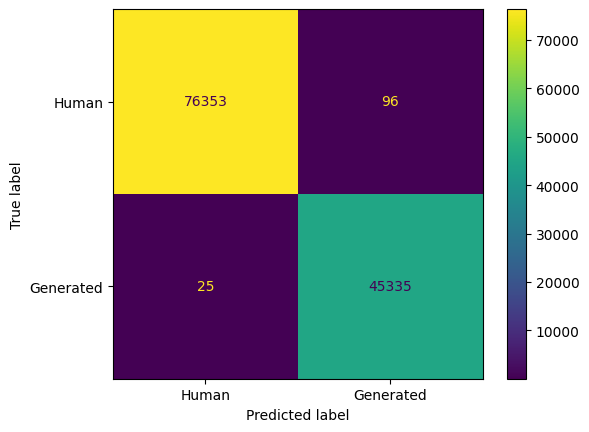

In [33]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Human", "Generated"])
disp.plot()
plt.show()

# 12. Predict Probability

In [34]:
def predict_proba(model, tokenizer, text, device):

    model.eval()

    encoding = tokenizer(
        text,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=128
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)

    ai_prob = probs[0][1].item()
    human_prob = probs[0][0].item()

    return {
        "ai_probability": ai_prob,
        "human_probability": human_prob
    }

In [50]:
print(predict_proba(model, tokenizer, """[Your Name]
[Your Address]
[City, State, ZIP]
[Email Address]
[Phone Number]
[Date]

[State Senator's Name]
[State Senator's Address]
[City, State, ZIP]

Subject: The Importance of the Electoral College in Presidential Elections

Dear [State Senator's Name],

I hope this letter finds you in good health and high spirits. I am writing to express my support for the Electoral College system and to urge you to uphold its presence in the presidential election process. While there are arguments in favor of switching to a popular vote system, the Electoral College remains a crucial institution that ensures fair representation and protects against the shortcomings of a direct election. 

The Electoral College was established by our founding fathers as a compromise between a Congressional vote and a popular vote. It consists of 538 electors, and a majority of 270 electoral votes is required to elect the President. Each state's allotment of electors is based on the number of representatives in the House of Representatives and its two Senators. This system ensures that every state, regardless of size, has a say in the election process.

One argument against the Electoral College is that it can lead to a discrepancy between the popular vote and the electoral vote. While this is true, it happens very rarely. In fact, since 1888, it has only occurred once in the year 2000. This demonstrates that the system is generally able to accurately reflect the will of the people. Moreover, the certainty of outcome provided by the Electoral College minimizes the likelihood of disputes over election results, as winning candidates tend to have a higher share of electoral votes compared to their share of the popular vote.

Another advantage of the Electoral College is that it promotes the idea of a united nation. Presidential candidates are required to have trans-regional appeal and must campaign throughout the country, not just in specific regions or swing states. This ensures that the President is not just a representative of one particular region, but a leader for the entire nation. It also prevents voters in non-swing states from feeling disenfranchised and disregarded, as candidates would have no incentive to campaign heavily in states they are sure to win.

The winner-take-all method of awarding electoral votes encourages candidates to focus their campaign efforts on swing states. This leads to more thoughtful and engaged voters in those states, as they know their votes will heavily influence the election outcome. Additionally, the Electoral College restores a balance of power between large and small states, ensuring that large states aren't solely monopolizing the attention of presidential candidates.

Lastly, the Electoral College prevents the need for run-off elections. Without this system, it is possible that no candidate would receive a majority of the votes cast, leading to time-consuming and complicated run-off elections. The Electoral College guarantees a clear winner and swift transition of power.

While the popular vote system may seem appealing in its simplicity, it neglects the diverse needs and interests of the states within our great nation. The Electoral College ensures that all states, regardless of size, are given a voice in the presidential election process. It encourages candidates to campaign nationally and represent the entire country, rather than focusing on specific regions or swing states.

In conclusion, the Electoral College serves as a vital safeguard in our democratic system. It promotes fair representation, encourages national campaigns, and prevents run-off elections. I urge you to consider these points and to support the preservation of the Electoral College. Thank you for your attention to this matter, and I look forward to your continued support.

Sincerely,

[Your Name]""", DEVICE))

{'ai_probability': 0.9999856948852539, 'human_probability': 1.424898346158443e-05}


# 13. Load Model

In [ ]:
def load_model():
    model = BERTClassifier()
    model.load_state_dict(torch.load("bert_classifier.pth", map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model